# 7CS033 Assignment Task 3

### Complete the following tasks.

#### You should comment on your code where appropriate. Failing to add comments may result in a mark deduction.

#### You should write any explainations in the report cell if the task explicitly asks for this or if you wish to expand upon your solution.

#### Ensure you have ran your code cell and printed any of the required outputs. If necessary you can use more than one code cell.

# Task

## TASK 3.1: Apply four classifiers discussed in Lecture 3, i.e. Support Vector Machine (SVM), Decision Tree (DT), Random Forest (RF), and K-nearest neighbours (KNN) classifiers to the adult_T3 dataset available on Canvas to predict the income column. Calculate the confusion matrix and evaluation metrics for all classifiers (25%):

## NOTE1: To decrease the processing time, use an ordinal encoder for both nominal and ordinal input columns. Use label encoding for the target feature.

## NOTE2 You are expected to improve your models to get as high accuracy as possible.

## NOTE3: You should add comments on your code wherever necessary and briefly explain what the code is doing

## NOTE4: Completing the report cell is NOT required. However, you can add explanations to the report cell if you need to do so.

## NOTE6: You will still get some marks if your code doesn't run, but you have written some codes and have added comments on the code.


In [82]:
############# WRITE YOUR CODE IN THIS CELL (IF APPLICABLE)####################

# Importing necessary Libraries which we would use 
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import train_test_split

from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import metrics



In [86]:
#Solution

df = pd.read_csv('adult_T3.csv')
df2 = df

#print a sample of the 5 data
print(df.sample(5))

#identify the number of missing values i
print(pd.isnull(df).sum());


      age         workclass  fnlwgt     education  education-num  \
1565   22           Private  362309  Some-college             10   
1961   19           Private  261259       HS-grad              9   
5894   38           Private  203763       HS-grad              9   
6517   49  Self-emp-not-inc  144351  Some-college             10   
4472   28           Private   60374       HS-grad              9   

          marital-status         occupation   relationship   race     sex  \
1565       Never-married      Other-service      Own-child  White    Male   
1961       Never-married  Handlers-cleaners      Own-child  White    Male   
5894            Divorced       Adm-clerical  Not-in-family  White  Female   
6517  Married-civ-spouse              Sales        Husband  White    Male   
4472  Married-civ-spouse      Other-service      Own-child  White  Female   

      capital-gain  capital-loss  hours-per-week native-country income  
1565             0             0              35  Unite

In [87]:
#Replace ? with empty in dataset
df2.replace("?", np.nan, inplace=True)

In [88]:
# Fill missing occupation values using education as a reference (related column)
df2["occupation"] = df2.groupby("education")["occupation"].transform(

    # x is the 'occupation' column for one education group
    lambda x: x.fillna(

        # If this education group has a most common value (mode),
        # use that to fill the missing values
        x.mode().iloc[0]

        # But only if the mode is not empty
        if not x.mode().empty

        # If this group has no valid occupation at all,
        # fall back to the global most common occupation
        else df2["occupation"].mode().iloc[0]
    )
)

print(pd.isnull(df2).sum());
#print(df.sample(5))

age                 0
workclass         582
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation          0
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    197
income              0
dtype: int64


In [89]:
# Fill missing native-country values using race as a reference (related column)
df2["native-country"] = df2.groupby("race")["native-country"].transform(

    # x is the 'native-country' column for one race group
    lambda x: x.fillna(

        # If this race group has a most common value (mode),
        # use that to fill the missing values
        x.mode().iloc[0] 

        # But only if the mode is not empty
        if not x.mode().empty 

        # If this group has no valid native-country at all,
        # fall back to the global most common native-country
        else df2["native-country"].mode()[0])
);

print(pd.isnull(df2).sum());


age                 0
workclass         582
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation          0
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country      0
income              0
dtype: int64


In [90]:
# Fill missing workclass values using race as a reference (related column)
df2["workclass"] = df2.groupby("occupation")["workclass"].transform(

    # x is the 'workclass' column for one race group
    lambda x: x.fillna(

        # If this occupation group has a most common value (mode),
        # use that to fill the missing values
        x.mode().iloc[0] 

        # But only if the mode is not empty
        if not x.mode().empty

        # If this group has no valid workclass at all,
        # fall back to the global most common native-country
        else df2["workclass"].mode()[0])
);

print(pd.isnull(df2).sum());


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [92]:

#label encoding for income, Sex, Workclass and other colums with string values

'''
df2['income'] = le.fit_transform(df2['income'])

df2['sex'] = le.fit_transform(df2['sex'])

df2['workclass'] = le.fit_transform(df2['workclass'])

df2['education'] = le.fit_transform(df2['education'])

df2['marital-status'] = le.fit_transform(df2['marital-status'])

df2['relationship'] = le.fit_transform(df2['relationship'])


df2['race'] = le.fit_transform(df2['race'])
df2['native-country'] = le.fit_transform(df2['native-country'])
df2['relationship'] = le.fit_transform(df2['relationship'])

df2['occupation'] = le.fit_transform(df2['occupation'])
'''




encoder = OrdinalEncoder()
categorical_cols = df2.select_dtypes(include='object').columns
df2[categorical_cols] = encoder.fit_transform(df2[categorical_cols])

le = LabelEncoder()
df2['income'] = le.fit_transform(df2['income'])

df2.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,29,3.0,216481,12.0,14,2.0,3.0,5.0,4.0,0.0,0,0,40,37.0,1
1,36,3.0,280570,15.0,10,2.0,2.0,0.0,4.0,1.0,0,0,45,37.0,0
2,25,3.0,100903,9.0,13,2.0,9.0,5.0,4.0,0.0,0,0,25,37.0,0
3,47,3.0,145636,8.0,11,2.0,5.0,0.0,4.0,1.0,0,0,48,37.0,1
4,33,3.0,119422,11.0,9,2.0,3.0,0.0,4.0,1.0,0,0,40,37.0,0


In [93]:
#delete  education-num and fnlwgt
df2 = df2.drop(['education-num', 'fnlwgt'], axis = 1);
df2.head()


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,29,3.0,12.0,2.0,3.0,5.0,4.0,0.0,0,0,40,37.0,1
1,36,3.0,15.0,2.0,2.0,0.0,4.0,1.0,0,0,45,37.0,0
2,25,3.0,9.0,2.0,9.0,5.0,4.0,0.0,0,0,25,37.0,0
3,47,3.0,8.0,2.0,5.0,0.0,4.0,1.0,0,0,48,37.0,1
4,33,3.0,11.0,2.0,3.0,0.0,4.0,1.0,0,0,40,37.0,0


In [95]:
#get value for x and y
X = df2.drop('income', axis=1)
y = df2['income']

#Scale the entire dataset without income
scaler = MinMaxScaler()
X = scaler.fit_transform(X)


X

array([[0.16438356, 0.42857143, 0.8       , ..., 0.        , 0.39795918,
        0.94871795],
       [0.26027397, 0.42857143, 1.        , ..., 0.        , 0.44897959,
        0.94871795],
       [0.10958904, 0.42857143, 0.6       , ..., 0.        , 0.24489796,
        0.94871795],
       ...,
       [0.17808219, 0.42857143, 0.73333333, ..., 0.        , 0.39795918,
        0.94871795],
       [0.32876712, 0.71428571, 0.53333333, ..., 0.        , 0.39795918,
        0.94871795],
       [0.05479452, 0.42857143, 1.        , ..., 0.        , 0.39795918,
        0.94871795]])

In [51]:


#Get X and Y dataset from df2



In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [99]:
# C controls regularization strength (Helps to to fit training data better)
# Using RBF kernel for non-linear decision boundaries
# random_state ensures reproducibility
SVM = svm.SVC(kernel='rbf', C=2, random_state=42)


# Decision Tree classifier
# random_state ensures reproducible results
DT = DecisionTreeClassifier(random_state=42)


# n_estimators = number of trees in the forest
# max_depth limits tree depth to prevent overfitting
# random_state ensures reproducibility
RF = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)


# n_neighbors defines how many nearby points influence classification
# Larger values reduce noise but may smooth decision boundaries
KNN = KNeighborsClassifier(n_neighbors=7)


SVM.fit(X_train, y_train)
DT.fit(X_train, y_train)
RF.fit(X_train, y_train)
KNN.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=7)

In [100]:
y

0       1
1       0
2       0
3       1
4       0
       ..
9995    0
9996    0
9997    0
9998    1
9999    0
Name: income, Length: 10000, dtype: int64

In [ ]:
#first make predictions using our trained models on the test data
#Now we can generate the confusion matrices

In [59]:
#A reusable helper function to Plot confusion matrix for all classifiers
def plot_confusion_for_all_models(model, X_test, y_test, title):
    
    #first make predictions using our trained models on the test data
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds, labels=model.classes_)

    #Now we can generate the confusion matrices
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=model.classes_)
    disp.plot()
    plt.title(title)
    plt.show()

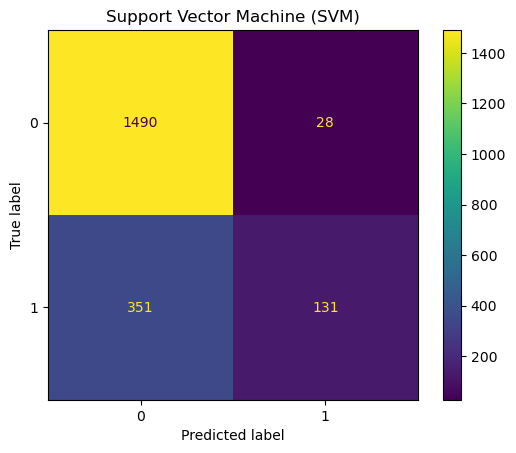

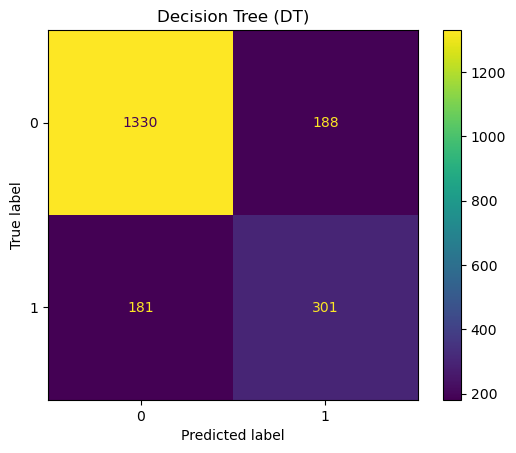

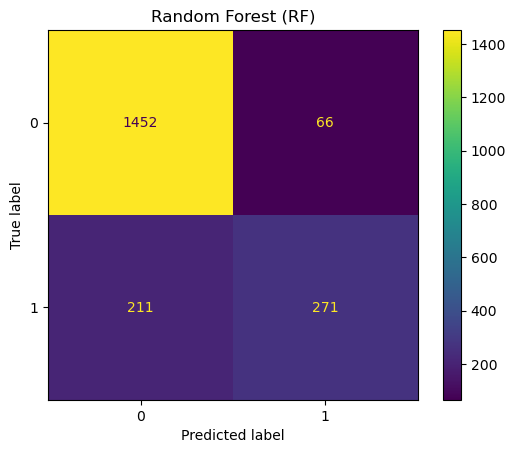

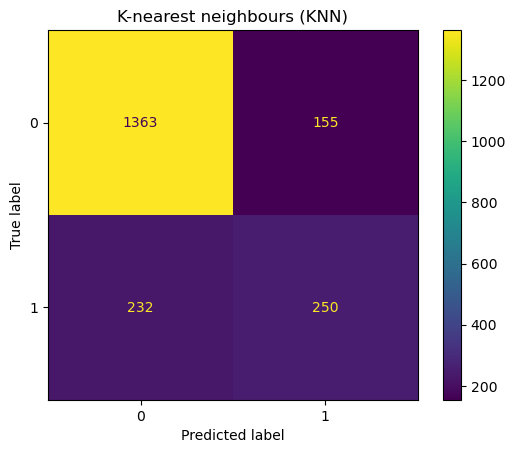

In [101]:
#Plot for 
#Support Vector Machine (SVM), Decision Tree (DT), Random Forest (RF), and K-nearest neighbours (KNN)
plot_confusion_for_all_models(SVM,X_test,y_test,'Support Vector Machine (SVM)');
plot_confusion_for_all_models(DT,X_test,y_test,'Decision Tree (DT)');
plot_confusion_for_all_models(RF,X_test,y_test,'Random Forest (RF)');
plot_confusion_for_all_models(KNN,X_test,y_test,'K-nearest neighbours (KNN)');



In [102]:

#A function to display accuracy, precision, recall and F1 score for the models
def confusion_Metrix_Analysis(y_test,X_test,model):
    model_prediction = model.predict(X_test)
    print(model,'METRICS')
    print('Accuracy: %.2f' %metrics.accuracy_score(y_test, model_prediction))
    print('Precision: %.2f' %metrics.precision_score(y_test, model_prediction))
    print('Recall: %.2f' %metrics.recall_score(y_test, model_prediction))
    print('F1 Score: %.2f \n' %metrics.f1_score(y_test, model_prediction))

In [103]:
from sklearn.metrics import classification_report
model_prediction = SVM.predict(X_test)
print(classification_report(y_test, model_prediction))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89      1518
           1       0.82      0.27      0.41       482

    accuracy                           0.81      2000
   macro avg       0.82      0.63      0.65      2000
weighted avg       0.81      0.81      0.77      2000



In [104]:
confusion_Metrix_Analysis(y_test,X_test,SVM);
confusion_Metrix_Analysis(y_test,X_test,DT);
confusion_Metrix_Analysis(y_test,X_test,RF);
confusion_Metrix_Analysis(y_test,X_test,KNN);







SVC(C=2, random_state=42) METRICS
Accuracy: 0.81
Precision: 0.82
Recall: 0.27
F1 Score: 0.41 

DecisionTreeClassifier(random_state=42) METRICS
Accuracy: 0.82
Precision: 0.62
Recall: 0.62
F1 Score: 0.62 

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42) METRICS
Accuracy: 0.86
Precision: 0.80
Recall: 0.56
F1 Score: 0.66 

KNeighborsClassifier(n_neighbors=7) METRICS
Accuracy: 0.81
Precision: 0.62
Recall: 0.52
F1 Score: 0.56 

